### Core Idea of Bayesian Optimization

Bayesian Optimization = **Surrogate Model** + **Acquisition Function** + **Iterative Update**

It can be summarized in one sentence:

> Use a cheap model to approximate an expensive real function, and then use a clever rule to decide where to test next.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# true function
# ==========================

def f(x):
    return np.sin(0.9 * x) + 0.2 * x


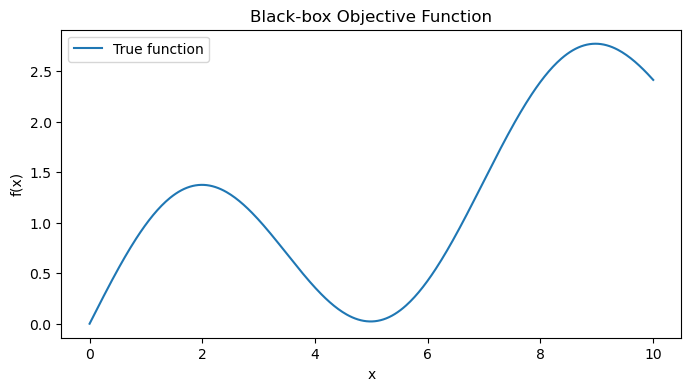

In [2]:
X_plot = np.linspace(0, 10, 400)
Y_plot = f(X_plot)

plt.figure(figsize=(8, 4))
plt.plot(X_plot, Y_plot, label='True function')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Black-box Objective Function')
plt.legend()
plt.show()

In [3]:

# ==========================
# kernel
# ==========================

def rbf_kernel(X1, X2, length_scale=1.0, sigma_f=1.0):
    X1 = np.atleast_2d(X1).reshape(-1, 1)
    X2 = np.atleast_2d(X2).reshape(-1, 1)
    
    sqdist = (X1 - X2.T) ** 2
    return sigma_f**2 * np.exp(-0.5 / length_scale**2 * sqdist)


In [4]:

# ==========================
# GP prediction
# ==========================

def gp_predict(X_train, y_train, X_test, length_scale=1.0, sigma_f=1.0, sigma_n=1e-6):
    X_train = np.asarray(X_train).reshape(-1, 1)
    y_train = np.asarray(y_train).reshape(-1, 1)
    X_test = np.asarray(X_test).reshape(-1, 1)
    
    K = rbf_kernel(X_train, X_train, length_scale, sigma_f) + sigma_n**2 * np.eye(len(X_train))
    K_s = rbf_kernel(X_train, X_test, length_scale, sigma_f)
    K_ss = rbf_kernel(X_test, X_test, length_scale, sigma_f) + 1e-10 * np.eye(len(X_test))
    
    K_inv = np.linalg.inv(K)
    
    mu_s = K_s.T @ K_inv @ y_train
    cov_s = K_ss - K_s.T @ K_inv @ K_s
    
    mu_s = mu_s.ravel()
    std_s = np.sqrt(np.maximum(np.diag(cov_s), 0))
    
    return mu_s, std_s, cov_s


### 测试一下 GP
>先随机选几个初始点：

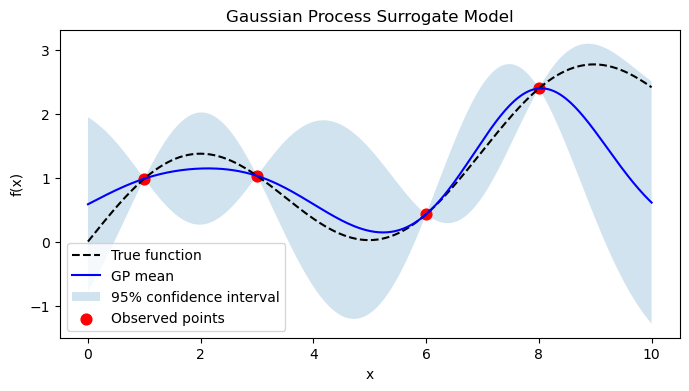

In [9]:
np.random.seed(42)

X_init = np.array([1.0, 3.0, 6.0, 8.0])
y_init = f(X_init)

mu, std, cov = gp_predict(X_init, y_init, X_plot, length_scale=1.2, sigma_f=1.0)
plt.figure(figsize=(8, 4))
plt.plot(X_plot, Y_plot, 'k--', label='True function')
plt.plot(X_plot, mu, 'b', label='GP mean')
plt.fill_between(X_plot,
                 mu - 1.96 * std,
                 mu + 1.96 * std,
                 alpha=0.2,
                 label='95% confidence interval')
plt.scatter(X_init, y_init, c='red', s=60, label='Observed points')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Gaussian Process Surrogate Model')
plt.legend()
plt.show()

### How to Choose the Next Point?

It is quite simple:
$$x_{next} = \arg \max_{x} a(x)$$

Where **$a(x)$** is the **Acquisition Function** (such as UCB, PI, or EI).

In [10]:
import math

def normal_pdf(z):
    return (1.0 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * z**2)

def normal_cdf(z):
    return 0.5 * (1 + np.vectorize(math.erf)(z / np.sqrt(2)))

<div style="font-size: 0.85em; line-height: 1.1;">

### UCB: Upper Confidence Bound

**Formula:**
$$\text{UCB}(x) = \mu(x) + \kappa\sigma(x)$$

**Where:**
* $\mu(x)$: Locations that currently look promising (Exploitation).
* $\sigma(x)$: Locations with high uncertainty (Exploration).
* $\kappa$: Controls the exploration intensity.

**Intuition:**
* **Large Mean** $\rightarrow$ Worth exploiting.
* **Large Uncertainty** $\rightarrow$ Worth exploring.
</div>

In [11]:
# UCB（Upper Confidence Bound）

def acquisition_ucb(mu, std, kappa=2.0):
    return mu + kappa * std

<div style="font-size: 0.85em; line-height: 1.1;">

### PI: Probability of Improvement

**Assume the current best value is:**
$$f_{best} = \max(y_1, \dots, y_n)$$

**Definition:**
$$Z(x) = \frac{\mu(x) - f_{best} - \xi}{\sigma(x)}$$

**PI is:**
$$\text{PI}(x) = \Phi(Z(x))$$

Where $\Phi$ is the **CDF of the standard normal distribution**.

**Meaning:**
> The probability of exceeding the current best value at point $x$.

</div>

<div style="font-size: 0.85em; line-height: 1.1;">

### Meaning of the Exploration Parameter $\xi$

**If $\xi = 0$:**
* Any possibility of being even slightly higher than the current best value counts as an improvement.

**If $\xi > 0$:**
* A point must be higher than the current best value by a significant margin to count as an improvement.

Therefore, **the larger $\xi$ is, the more "strict" PI, EI (Probability of Improvement) becomes**, favoring more aggressive exploration.
</div>

In [12]:
# PI（Probability of Improvement）

def acquisition_pi(mu, std, y_best, xi=0.01):
    std = np.maximum(std, 1e-12)
    z = (mu - y_best - xi) / std
    return normal_cdf(z)

<div style="font-size: 0.85em; line-height: 1.1;">

### EI: Expected Improvement

The definition of EI is more commonly used:
$$\text{EI}(x) = \mathbb{E}[\max(f(x) - f_{best} - \xi, 0)]$$

The closed-form solution is:
$$\text{EI}(x) = (\mu(x) - f_{best} - \xi)\Phi(Z) + \sigma(x)\phi(Z)$$

Where:
$$Z = \frac{\mu(x) - f_{best} - \xi}{\sigma(x)}$$

* $\phi$ is the **PDF** of the standard normal distribution.
* $\Phi$ is the **CDF** of the standard normal distribution.

**Intuition:**
* If the **mean** at a certain point is high, EI is large.
* If the **uncertainty** at a certain point is large, EI may also be large.

Therefore, **EI is often more balanced than PI**.

</div>

In [ ]:
# EI（Expected Improvement）
def acquisition_ei(mu, std, y_best, xi=0.01):
    std = np.maximum(std, 1e-12)
    z = (mu - y_best - xi) / std
    ei = (mu - y_best - xi) * normal_cdf(z) + std * normal_pdf(z)
    
    # 关键：只在“数组情况下”才做 masking
    if ei.ndim > 0:
        ei[std < 1e-12] = 0.0
    elif std < 1e-12:
        ei = 0.0
    return ei

In [ ]:
mu = 10.2
sigma = 0.3
f_best = 10.0

# 随着 ξ 增大, PI 和 EI 往往都会下降, 因为“改进门槛”变高了

for xi in [0.0, 0.1, 0.5]:
    pi = acquisition_pi(mu, sigma, f_best, xi)
    ei = acquisition_ei(mu, sigma, f_best, xi)
    print(f"xi={xi:.1f}, PI={pi:.4f}, EI={ei:.4f}")

xi=0.0, PI=0.7475, EI=0.2453
xi=0.1, PI=0.6306, EI=0.1763
xi=0.5, PI=0.1587, EI=0.0250


In [15]:
y_best = np.max(y_init)

ucb = acquisition_ucb(mu, std, kappa=2.0)
pi = acquisition_pi(mu, std, y_best, xi=0.01)
ei = acquisition_ei(mu, std, y_best, xi=0.01)

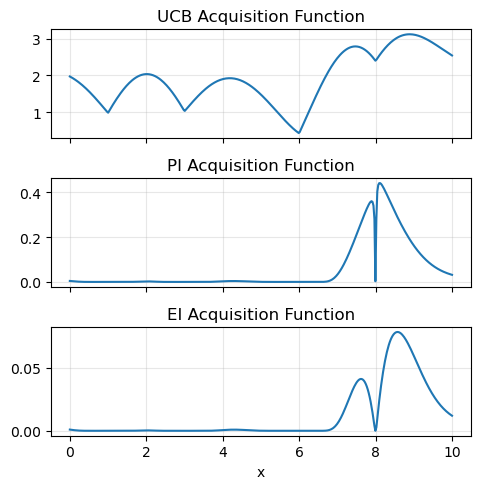

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(5, 5), sharex=True)

axes[0].plot(X_plot, ucb)
axes[0].set_title('UCB Acquisition Function')

axes[1].plot(X_plot, pi)
axes[1].set_title('PI Acquisition Function')

axes[2].plot(X_plot, ei)
axes[2].set_title('EI Acquisition Function')
axes[2].set_xlabel('x')

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
def propose_next_point(X_candidates, acquisition_values):
    idx = np.argmax(acquisition_values)
    return X_candidates[idx]

In [19]:
x_next = propose_next_point(X_plot, ei)
y_next = f(x_next)

print("Next point selected by EI:", x_next)
print("True function value at this point:", y_next)

Next point selected by EI: 8.571428571428571
True function value at this point: 2.7045440970313495


In [20]:
def plot_bo_step(X_train, y_train, X_grid, y_true, mu, std, acq, x_next, acq_name='EI'):
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    
    # 上图：真实函数 + GP
    axes[0].plot(X_grid, y_true, 'k--', label='True function')
    axes[0].plot(X_grid, mu, 'b', label='GP mean')
    axes[0].fill_between(X_grid,
                         mu - 1.96 * std,
                         mu + 1.96 * std,
                         alpha=0.2,
                         label='95% CI')
    axes[0].scatter(X_train, y_train, c='red', s=60, label='Observed points')
    axes[0].axvline(x_next, color='green', linestyle='--', label='Next point')
    axes[0].set_title('Surrogate Model (GP)')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # 下图：采集函数
    axes[1].plot(X_grid, acq, color='purple', label=f'{acq_name}')
    axes[1].axvline(x_next, color='green', linestyle='--', label='Selected point')
    axes[1].set_title(f'Acquisition Function: {acq_name}')
    axes[1].set_xlabel('x')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [21]:
def bayesian_optimization(
    f,
    bounds,
    n_init=4,
    n_iter=8,
    acquisition='ei',
    length_scale=1.2,
    sigma_f=1.0,
    sigma_n=1e-6,
    kappa=2.0,
    xi=0.01,
    random_state=42
):
    np.random.seed(random_state)
    
    # 1. 初始化
    X_train = np.random.uniform(bounds[0], bounds[1], size=n_init)
    X_train = np.sort(X_train)
    y_train = f(X_train)
    
    X_grid = np.linspace(bounds[0], bounds[1], 500)
    y_true = f(X_grid)
    
    history = []
    
    for step in range(n_iter):
        # 2. 训练 GP
        mu, std, _ = gp_predict(
            X_train, y_train, X_grid,
            length_scale=length_scale,
            sigma_f=sigma_f,
            sigma_n=sigma_n
        )
        
        # 3. 计算采集函数
        y_best = np.max(y_train)
        
        if acquisition.lower() == 'ucb':
            acq = acquisition_ucb(mu, std, kappa=kappa)
        elif acquisition.lower() == 'pi':
            acq = acquisition_pi(mu, std, y_best, xi=xi)
        elif acquisition.lower() == 'ei':
            acq = acquisition_ei(mu, std, y_best, xi=xi)
        else:
            raise ValueError("acquisition must be 'ucb', 'pi', or 'ei'")
        
        # 4. 选取下一个点
        x_next = X_grid[np.argmax(acq)]
        y_next = f(x_next)
        
        # 5. 可视化
        print(f"Iteration {step+1}")
        print(f"Current best x = {X_train[np.argmax(y_train)]:.4f}, best y = {np.max(y_train):.4f}")
        print(f"Next point x_next = {x_next:.4f}, y_next = {y_next:.4f}")
        
        plot_bo_step(X_train, y_train, X_grid, y_true, mu, std, acq, x_next, acq_name=acquisition.upper())
        
        # 6. 更新数据集
        X_train = np.append(X_train, x_next)
        y_train = np.append(y_train, y_next)
        
        # 排序仅为方便画图和查看
        idx = np.argsort(X_train)
        X_train = X_train[idx]
        y_train = y_train[idx]
        
        history.append((X_train.copy(), y_train.copy()))
    
    best_idx = np.argmax(y_train)
    return X_train, y_train, X_train[best_idx], y_train[best_idx], history

Iteration 1
Current best x = 9.5071, best y = 2.6647
Next point x_next = 8.8176, y_next = 2.7602


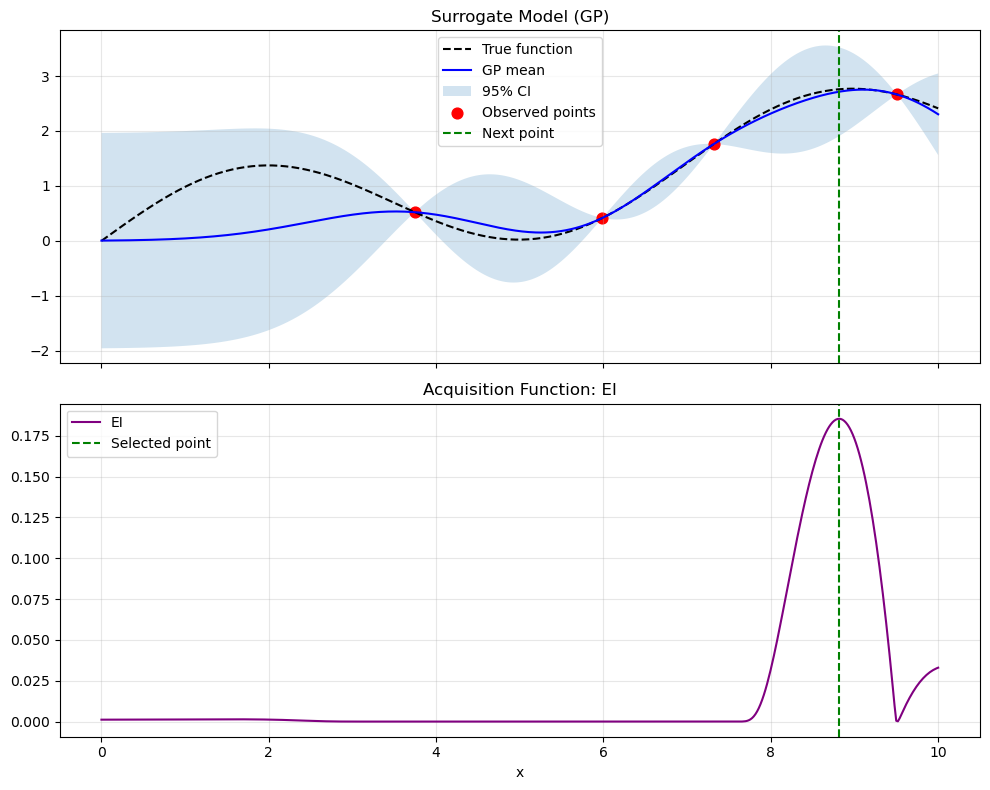

Iteration 2
Current best x = 8.8176, best y = 2.7602
Next point x_next = 9.0782, y_next = 2.7660


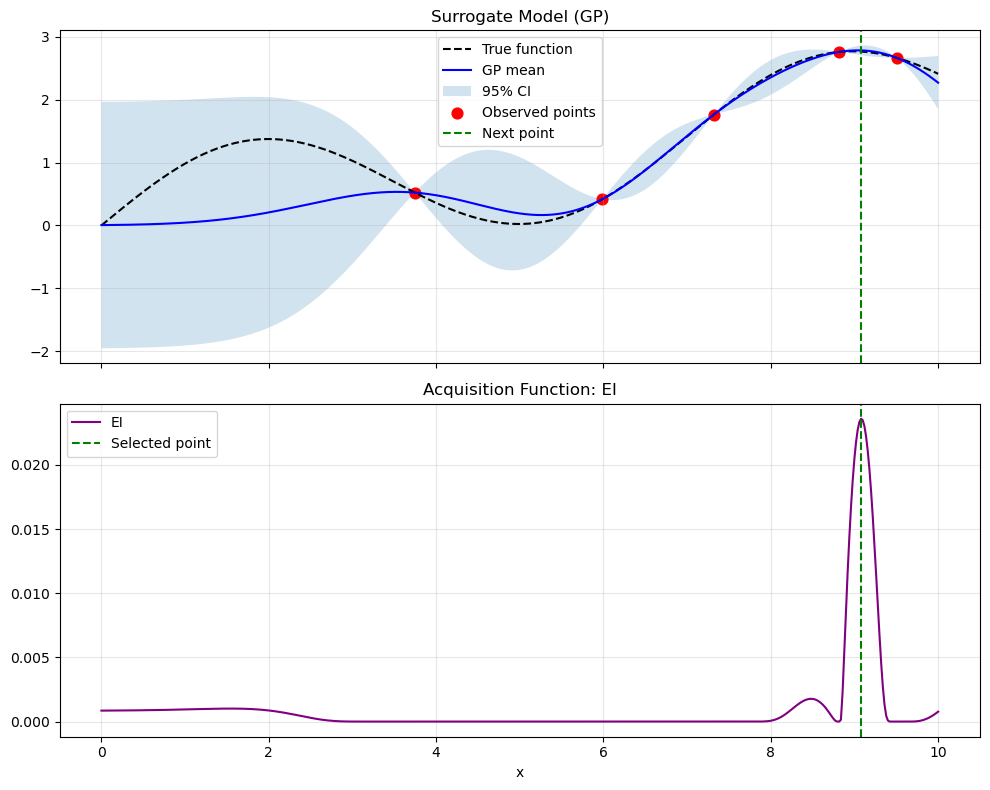

Iteration 3
Current best x = 9.0782, best y = 2.7660
Next point x_next = 1.5030, y_next = 1.2769


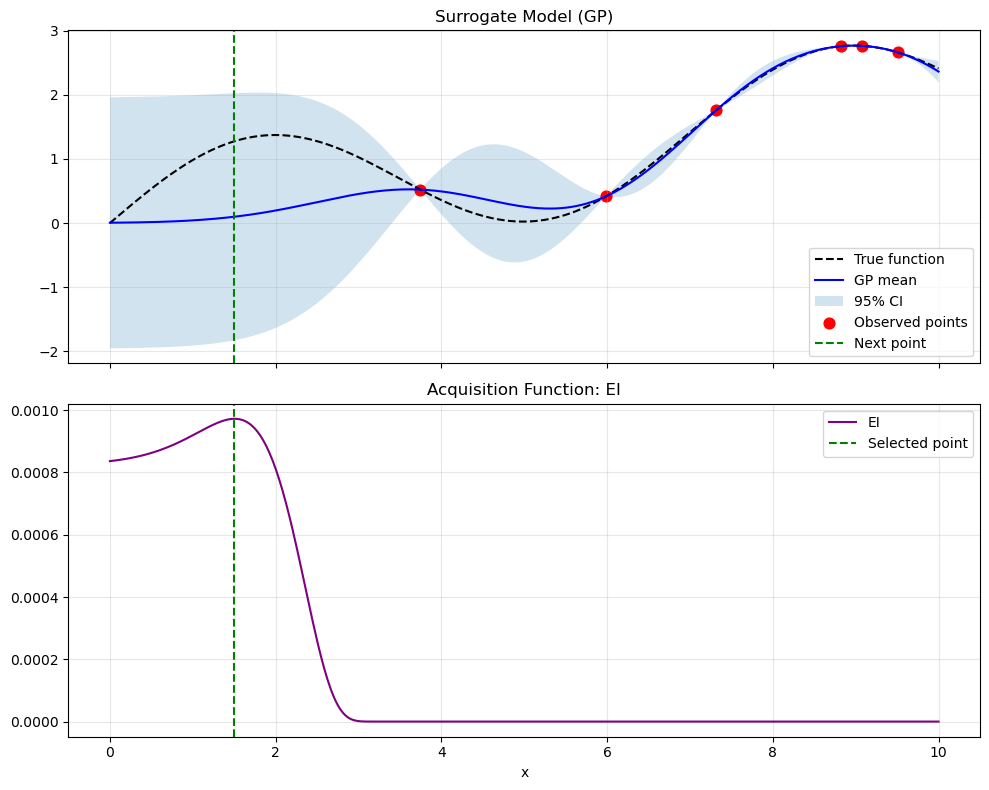

Iteration 4
Current best x = 9.0782, best y = 2.7660
Next point x_next = 0.0000, y_next = 0.0000


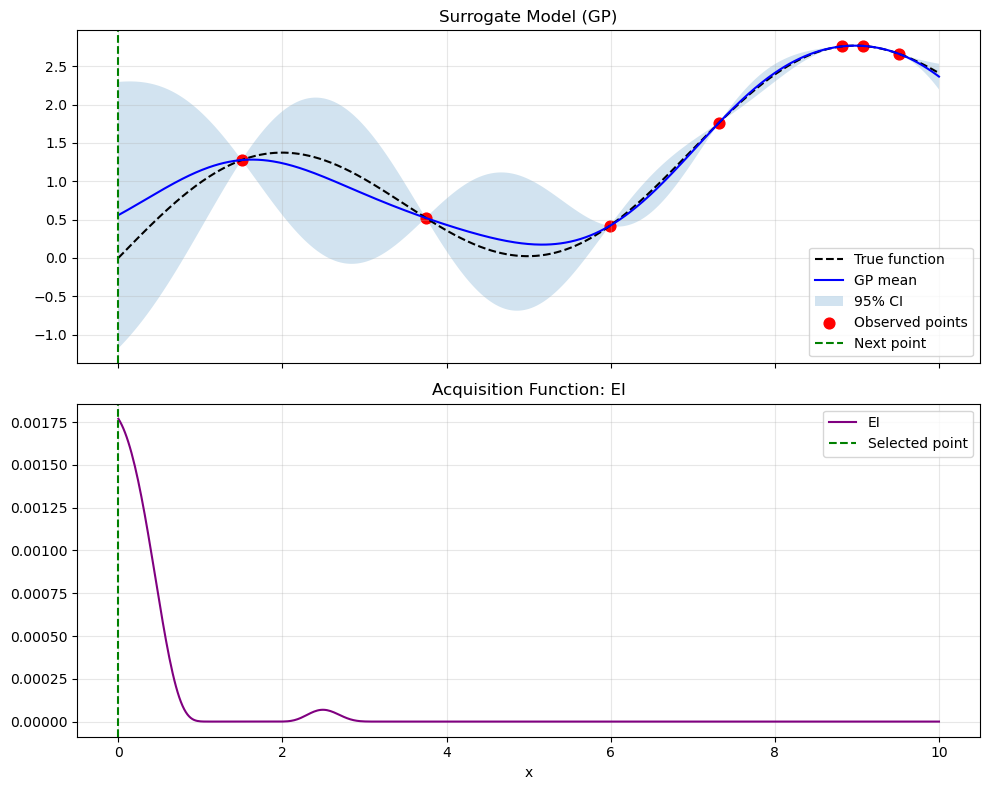

Iteration 5
Current best x = 9.0782, best y = 2.7660
Next point x_next = 2.5251, y_next = 1.2687


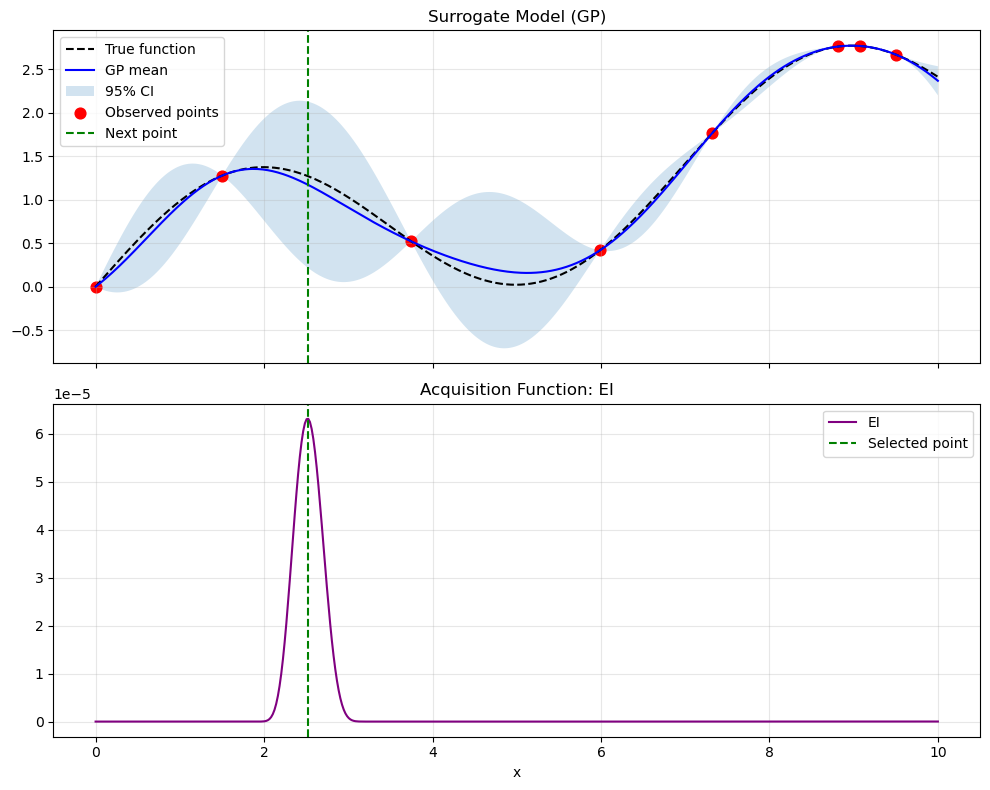

Iteration 6
Current best x = 9.0782, best y = 2.7660
Next point x_next = 10.0000, y_next = 2.4121


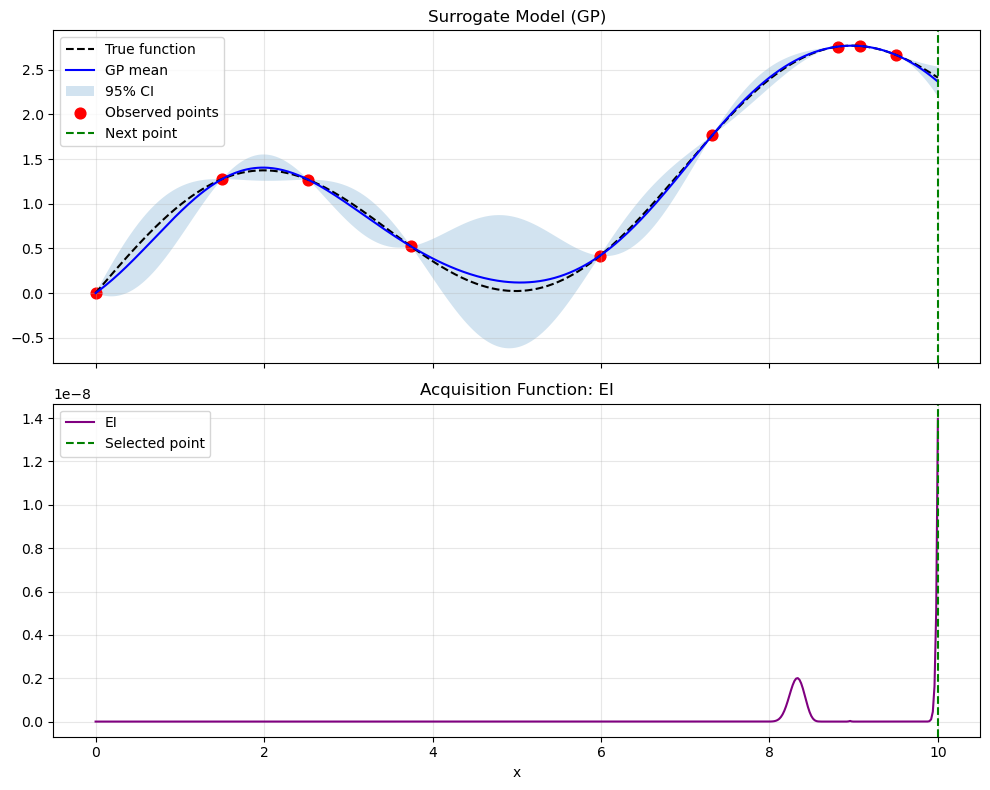

In [22]:
X_obs, y_obs, x_best, y_best, history = bayesian_optimization(
    f=f,
    bounds=(0, 10),
    n_init=4,
    n_iter=6,
    acquisition='ei',   # 可改成 'ucb' 或 'pi'
    length_scale=1.2,
    sigma_f=1.0,
    sigma_n=1e-6,
    xi=0.01,
    random_state=42
)

In [23]:
print("Final best point:")
print("x_best =", x_best)
print("y_best =", y_best)

Final best point:
x_best = 9.07815631262525
y_best = 2.766005708237681
